In [33]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [34]:
import numpy as np
import pandas as pd

In [35]:
#  ====
# Inputs for creating strat model with gempy
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [36]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

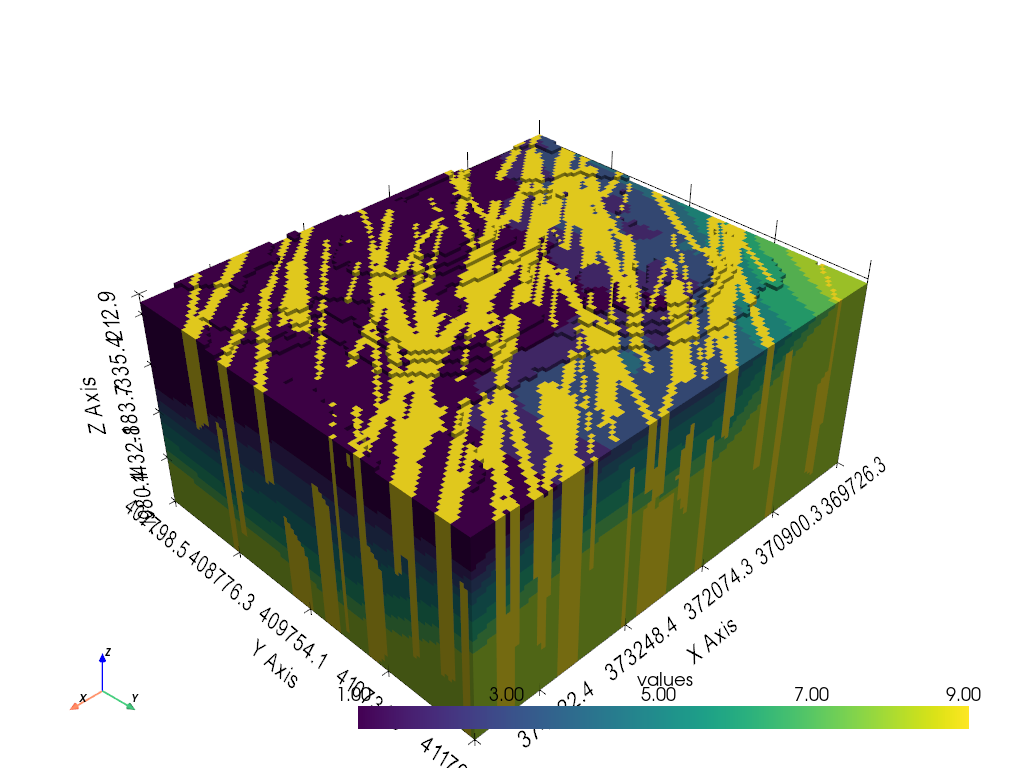

In [37]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [38]:
import numpy as np

# ============================================================
# INPUTS
# ============================================================

# geomodel : lithology cube
# shape = (NX, NY, NZ)
#
# lithology IDs:
# 0 = air
# 1-9 = rock types

AIR_CODE = 0
#perm in mD

rock_props = {
    1: {"poro": 0.2, "permx": 50}, #top
    2: {"poro": 0.02, "permx": 1e-2}, #B1
    3: {"poro": 0.2, "permx": 50}, #M1
    4: {"poro": 0.02, "permx": 1e-2}, #B2
    5: {"poro": 0.2, "permx": 50}, #M2
    6: {"poro": 0.02, "permx": 1e-2}, #B3
    7: {"poro": 0.2, "permx": 50}, #M3
    8: {"poro": 0.02, "permx": 1e-2}, #B4
    9: {"poro": 0.1, "permx": 1e3}, #faults -- good o.o.m. but check porosity
}

output_file = "reservoir.grdecl"

# ============================================================
# HELPERS
# ============================================================

def centers_to_edges(c):
    c = np.asarray(c)

    edges = np.empty(len(c) + 1)

    edges[1:-1] = (c[:-1] + c[1:]) / 2

    edges[0] = c[0] - (c[1] - c[0]) / 2
    edges[-1] = c[-1] + (c[-1] - c[-2]) / 2

    return edges


def write_keyword_array(f, keyword, arr):

    f.write(f"{keyword}\n")

    values = np.asarray(arr).flatten(order="F")

    for i, v in enumerate(values):

        if np.issubdtype(type(v), np.integer):
            f.write(f"{int(v)} ")
        else:
            f.write(f"{float(v):.6g} ")

        if (i + 1) % 8 == 0:
            f.write("\n")

    f.write("\n/\n\n")


# ============================================================
# GRID
# ============================================================

lith = geomodel.astype(int)

NX, NY, NZ = lith.shape

x_edges = centers_to_edges(x_array)
y_edges = centers_to_edges(y_array)
z_edges = centers_to_edges(z_array)

# ============================================================
# ACTNUM
# ============================================================

# Air cells inactive
actnum = (lith != AIR_CODE).astype(int)

# ============================================================
# ROCK PROPERTIES
# ============================================================

poro = np.zeros_like(lith, dtype=float)
permx = np.zeros_like(lith, dtype=float)

for facies, props in rock_props.items():

    mask = lith == facies

    poro[mask] = props["poro"]
    permx[mask] = props["permx"]

# ============================================================
# WRITE GRDECL
# ============================================================

with open(output_file, "w") as f:

    # --------------------------------------------------------
    # SPECGRID
    # --------------------------------------------------------

    f.write("SPECGRID\n")
    f.write(f"{NX} {NY} {NZ} 1 F /\n\n")

    # --------------------------------------------------------
    # COORD
    # --------------------------------------------------------

    f.write("COORD\n")

    z_top = z_edges[0]
    z_bottom = z_edges[-1]

    for y in y_edges:
        for x in x_edges:

            f.write(
                f"{x:.6f} {y:.6f} {z_top:.6f} "
                f"{x:.6f} {y:.6f} {z_bottom:.6f}\n"
            )

    f.write("/\n\n")

    # --------------------------------------------------------
    # ZCORN
    # --------------------------------------------------------

    f.write("ZCORN\n")

    counter = 0

    for k in range(NZ):

        top = z_edges[k]
        bottom = z_edges[k + 1]

        for _ in range(NX * NY):

            vals = [
                top, top, top, top,
                bottom, bottom, bottom, bottom
            ]

            for v in vals:

                f.write(f"{v:.6f} ")

                counter += 1

                if counter % 8 == 0:
                    f.write("\n")

    f.write("/\n\n")

    # --------------------------------------------------------
    # ACTNUM
    # --------------------------------------------------------

    write_keyword_array(f, "ACTNUM", actnum)

    # --------------------------------------------------------
    # FACIES
    # --------------------------------------------------------

    write_keyword_array(f, "FACIES", lith)

    # --------------------------------------------------------
    # PORO
    # --------------------------------------------------------

    write_keyword_array(f, "PORO", poro)

    # --------------------------------------------------------
    # PERMX
    # --------------------------------------------------------

    write_keyword_array(f, "PERMX", permx)

print(f"Written: {output_file}")
print(f"Grid dimensions: {NX} x {NY} x {NZ}")
print(f"Total cells: {NX*NY*NZ:,}")
print(f"Active cells: {actnum.sum():,}")
print(f"Inactive air cells: {(actnum == 0).sum():,}")

Written: reservoir.grdecl
Grid dimensions: 100 x 100 x 60
Total cells: 600,000
Active cells: 518,499
Inactive air cells: 81,501


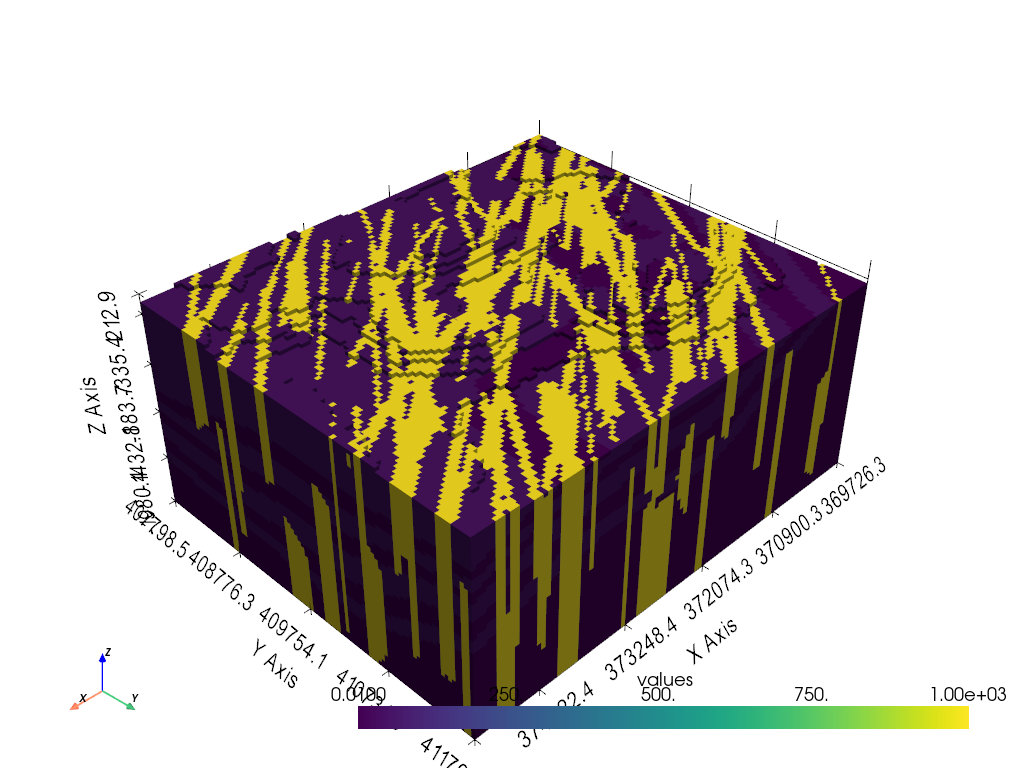

In [39]:
geomodel_toolbox.plot_3d_model(permx, x_array, y_array, z_array)